In [20]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [21]:
load_dotenv()

True

In [22]:
llm = HuggingFaceEndpoint(
    repo_id="google/gemma-4-31B-it",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

In [23]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [24]:
def llm_outline_gen(state: BlogState) -> BlogState:
    prompt = f'Generate a detailed outline for a blog on the topic - {state["title"]}'
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [25]:
def llm_output_gen(state: BlogState) -> BlogState:
    prompt = f'Generate a creative blog post on the topic - {state["title"]} and outline - {state["outline"]}'
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [26]:
graph = StateGraph(BlogState)

graph.add_node("LLM Outline Generation",llm_outline_gen)
graph.add_node("LLM Content Generation",llm_output_gen)
graph.add_edge(START, "LLM Outline Generation")
graph.add_edge("LLM Outline Generation", "LLM Content Generation")
graph.add_edge("LLM Content Generation", END)

workflow = graph.compile()

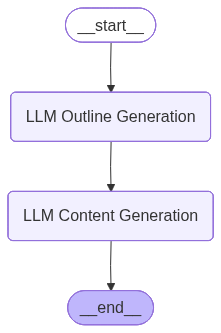

In [27]:
workflow

In [29]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state['content'])
print(final_state['outline'])